In [1]:
# ============================================================
# Cell 1: 初始化
# ============================================================
setwd("/home/ailab/caohao/AdaDiss/")

suppressPackageStartupMessages({
    library(Seurat)
    library(harmony)
    library(dplyr)
    library(ggplot2)
    library(Matrix)
})

paths <- list(
    raw = list(
        scrna_dir    = "./data/raw/scrna/GSE264393_RAW/",
        xenium_dir   = "./data/raw/xenium/GSE264334_RAW/",
        xenium_cells = "./data/raw/xenium/GSE264334_RAW/cells.csv.gz"
    ),
    cache = list(
        # 中间缓存（不含细胞类型注释，合并+降维+聚类完成后保存）
        scrna_clustered  = "./data/cache/kidney_scrna_clustered.rds",
        # 中间缓存（FindAllMarkers 结果，计算耗时约 10-20 分钟）
        markers          = "./data/cache/kidney_markers.rds",
        # 最终缓存（含 cell_type 注释，Cell 4 完成后保存）
        scrna_final      = "./data/cache/kidney_scrna_processed.rds",
        # Xenium 基础缓存（加载坐标后，未做标签转移）
        xenium_base      = "./data/cache/kidney_xenium_base.rds",
        # Xenium 最终缓存（含 Seurat 标签转移结果）
        xenium_final     = "./data/cache/kidney_xenium_processed.rds"
    )
)
for (d in c("./data/cache", "./results", "./plots")) {
    dir.create(d, showWarnings = FALSE, recursive = TRUE)
}

params <- list(
    min_features  = 500,
    max_features  = 6000,
    max_counts    = 25000,
    max_mt_pct    = 25,
    n_pcs         = 30,
    cluster_res   = 0.5,
    harmony_theta = 2
)
SAMPLES <- c("A1", "C3", "C4", "C5")

# 缓存状态一览
cat("=== 缓存状态 ===\n")
for (nm in names(paths$cache)) {
    exists <- file.exists(paths$cache[[nm]])
    size   <- if (exists) paste0(round(file.size(paths$cache[[nm]])/1e6, 1), " MB") else "-"
    cat(sprintf("  %-20s %s  %s\n", nm,
                if (exists) "[HIT]" else "[MISS]", size))
}
cat("\n")

=== 缓存状态 ===
  scrna_clustered      [HIT]  1224.5 MB
  markers              [HIT]  0.1 MB
  scrna_final          [MISS]  -
  xenium_base          [MISS]  -
  xenium_final         [MISS]  -



[Cache HIT] 加载 scRNA 聚类中间缓存...
  细胞数 : 79826 
  聚类数 : 25 
  请继续运行 Cell 3 查看 marker，然后在 Cell 4 填写注释


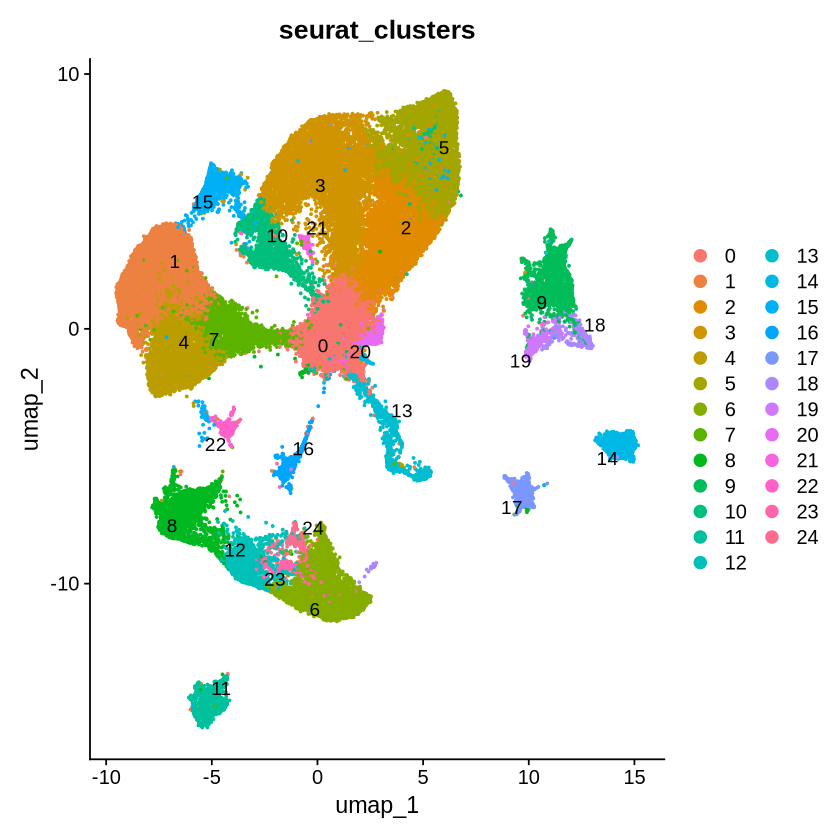

In [2]:
# ============================================================
# Cell 2: scRNA 加载、QC、降维、聚类
# 缓存策略：
#   kidney_scrna_final 存在    → 直接加载（跳过全部）
#   kidney_scrna_clustered 存在 → 跳过构建，只加载聚类结果
#   两者都不存在               → 从原始文件重新构建
# ============================================================

if (file.exists(paths$cache$scrna_final)) {
    # ── 情况 A：最终缓存存在（含 cell_type），直接加载 ──────────
    cat("[Cache HIT] 加载最终 scRNA 缓存（含细胞类型注释）...\n")
    scrna_obj <- readRDS(paths$cache$scrna_final)
    cat("  细胞数 :", ncol(scrna_obj), "\n")
    cat("  细胞类型:", paste(sort(unique(scrna_obj$cell_type)),
                           collapse = ", "), "\n")

} else if (file.exists(paths$cache$scrna_clustered)) {
    # ── 情况 B：中间缓存存在（聚类完成，未注释），跳过耗时构建 ──
    cat("[Cache HIT] 加载 scRNA 聚类中间缓存...\n")
    scrna_obj <- readRDS(paths$cache$scrna_clustered)
    cat("  细胞数 :", ncol(scrna_obj), "\n")
    cat("  聚类数 :", length(unique(scrna_obj$seurat_clusters)), "\n")
    cat("  请继续运行 Cell 3 查看 marker，然后在 Cell 4 填写注释\n")

} else {
    # ── 情况 C：无缓存，从原始文件构建（最耗时，约 30-60 分钟）──
    cat("[Cache MISS] 从原始文件构建 scRNA 对象...\n")

    # 加载 4 个样本
    obj_list <- list()
    for (sample in SAMPLES) {
        cat("  加载样本", sample, "...\n")
        tmp <- file.path(tempdir(), sample)
        dir.create(tmp, showWarnings = FALSE)
        for (f in c("barcodes.tsv.gz", "features.tsv.gz", "matrix.mtx.gz")) {
            prefix <- sub("\\..*", "", f)  # barcodes / features / matrix
            file.copy(
                file.path(paths$raw$scrna_dir, paste0(sample, "_", f)),
                file.path(tmp, f)
            )
        }
        obj <- CreateSeuratObject(
            counts = Read10X(data.dir = tmp),
            project = sample, min.cells = 3, min.features = 200
        )
        obj$sample <- sample
        obj_list[[sample]] <- obj
        cat("    核数:", ncol(obj), "\n")
    }

    scrna_raw <- merge(obj_list[[1]], y = obj_list[-1],
                       add.cell.ids = SAMPLES)
    cat("合并后:", ncol(scrna_raw), "核\n")

    # Seurat v5：merge 后必须 JoinLayers
    scrna_raw <- JoinLayers(scrna_raw)

    # QC 过滤
    scrna_raw[["percent.mt"]] <- PercentageFeatureSet(
        scrna_raw, pattern = "^MT-")
    scrna_filt <- subset(scrna_raw,
        subset = nFeature_RNA > params$min_features &
                 nFeature_RNA < params$max_features &
                 nCount_RNA   < params$max_counts   &
                 percent.mt   < params$max_mt_pct)
    cat("QC 过滤后:", ncol(scrna_filt), "核\n")

    # 标准化 + PCA + Harmony + UMAP + 聚类
    cat("标准化 + PCA...\n")
    scrna_obj <- scrna_filt %>%
        NormalizeData(verbose = FALSE) %>%
        FindVariableFeatures(nfeatures = 3000, verbose = FALSE) %>%
        ScaleData(verbose = FALSE) %>%
        RunPCA(npcs = params$n_pcs, verbose = FALSE)

    cat("Harmony 批次校正...\n")
    scrna_obj <- RunHarmony(scrna_obj,
        group.by.vars = "sample",
        theta = params$harmony_theta, verbose = FALSE)

    cat("UMAP + 聚类...\n")
    scrna_obj <- scrna_obj %>%
        RunUMAP(reduction = "harmony",
                dims = 1:params$n_pcs, verbose = FALSE) %>%
        FindNeighbors(reduction = "harmony",
                      dims = 1:params$n_pcs, verbose = FALSE) %>%
        FindClusters(resolution = params$cluster_res, verbose = FALSE)
    cat("聚类数:", length(unique(scrna_obj$seurat_clusters)), "\n")

    # 保存中间缓存（聚类完成，未注释）
    saveRDS(scrna_obj, paths$cache$scrna_clustered)
    cat("✅ 中间缓存已保存:", paths$cache$scrna_clustered, "\n")
    cat("   下次运行将直接从此处加载，跳过合并/QC/降维/聚类\n")
}

DimPlot(scrna_obj,
    group.by = ifelse("cell_type" %in% colnames(scrna_obj@meta.data),
                      "cell_type", "seurat_clusters"),
    reduction = "umap", label = TRUE, repel = TRUE, pt.size = 0.3)

[Cache HIT] 加载 marker 缓存...
  共 4305 个 marker 基因
# A tibble: 45 × 4
# Groups:   cluster [9]
   cluster gene       avg_log2FC pct.1
   <chr>   <chr>           <dbl> <dbl>
 1 0       LINGO1           2.25 0.282
 2 0       CLCNKA           2.02 0.316
 3 0       CLCNKB           1.55 0.309
 4 0       MYO15B           1.44 0.229
 5 0       LENG8            1.42 0.214
 6 13      CARMN            7.20 0.391
 7 13      PRR16            6.21 0.279
 8 13      NTRK3            5.86 0.31 
 9 13      C7               5.81 0.25 
10 13      ANO3             5.37 0.303
11 14      AC074031.1       7.85 0.489
12 14      C3orf79          6.37 0.405
13 14      AC008011.2       6.27 0.343
14 14      PTPRQ            6.21 0.948
15 14      NKD1             6.13 0.636
16 17      KIRREL3          5.99 0.508
17 17      CFH              5.91 0.732
18 17      SLC4A11          5.65 0.483
19 17      TNC              5.61 0.426
20 17      KLRG2            5.51 0.461
21 2       CYP3A5           2.21 0.502
22 2       

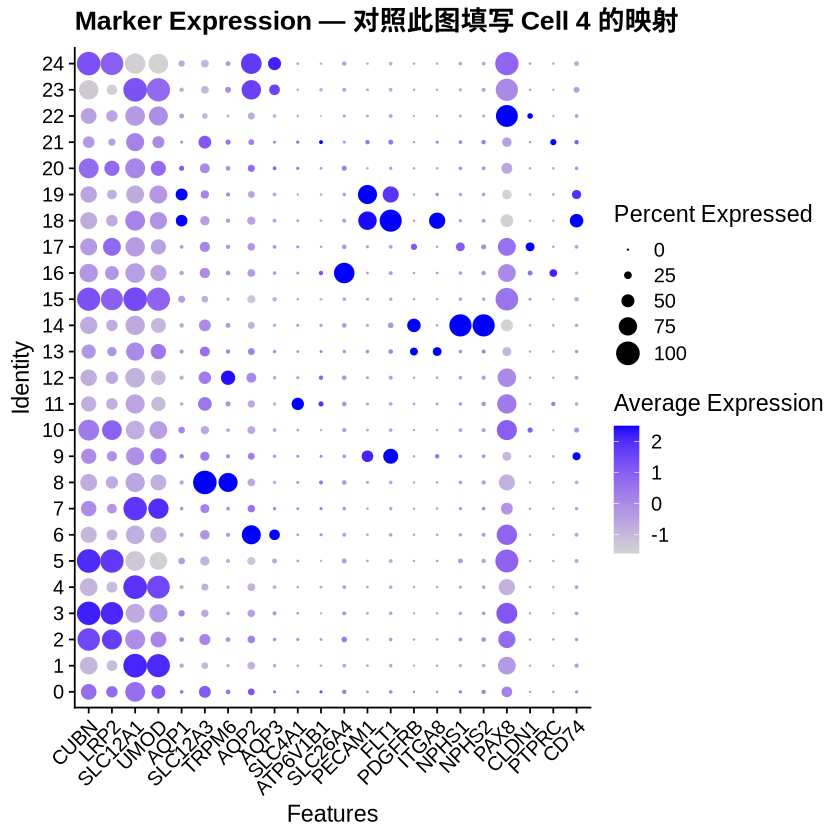

In [3]:
# ============================================================
# Cell 3: 查看 Marker 基因
# 缓存策略：
#   markers.rds 存在      → 直接加载（跳过 FindAllMarkers）
#   cell_type 已存在      → 跳过整个 Cell
#   两者都不存在          → 计算并保存
# ============================================================

if ("cell_type" %in% colnames(scrna_obj@meta.data)) {
    cat("已有 cell_type 注释，跳过 marker 计算\n")

} else {
    # Seurat v5：确保 layers 已合并
    scrna_obj <- JoinLayers(scrna_obj)

    if (file.exists(paths$cache$markers)) {
        cat("[Cache HIT] 加载 marker 缓存...\n")
        markers <- readRDS(paths$cache$markers)
        cat("  共", nrow(markers), "个 marker 基因\n")
    } else {
        cat("[Cache MISS] 计算 marker genes（约 10-20 分钟）...\n")
        markers <- FindAllMarkers(
            scrna_obj, only.pos = TRUE,
            min.pct = 0.25, logfc.threshold = 0.25, verbose = FALSE
        )
        if (nrow(markers) > 0) {
            saveRDS(markers, paths$cache$markers)
            cat("✅ marker 缓存已保存:", paths$cache$markers, "\n")
        } else {
            warning("FindAllMarkers 返回空结果")
        }
    }

    if (nrow(markers) > 0) {
        top5 <- markers %>%
            mutate(cluster = as.character(cluster)) %>%
            group_by(cluster) %>%
            slice_max(avg_log2FC, n = 5) %>%
            select(cluster, gene, avg_log2FC, pct.1)
        print(top5, n = Inf)
    }

    # DotPlot：参考标志基因辅助注释
    kidney_markers <- list(
        PCT   = c("CUBN", "LRP2", "SLC5A2"),
        TAL   = c("SLC12A1", "UMOD", "CLDN16"),
        LOH   = c("SLC12A1", "AQP1"),
        DCT   = c("SLC12A3", "TRPM6", "CALB1"),
        PC    = c("AQP2", "AQP3", "FXYD4"),
        `IC-A`= c("SLC4A1", "ATP6V1B1"),
        `IC-B`= c("SLC26A4"),
        ENDO  = c("PECAM1", "FLT1", "EMCN"),
        MES   = c("PDGFRB", "ITGA8"),
        POD   = c("NPHS1", "NPHS2", "SYNPO"),
        PEC   = c("PAX8", "CLDN1"),
        LEU   = c("PTPRC", "CD74")
    )
    flat <- unique(unlist(lapply(kidney_markers, head, 2)))
    flat <- flat[flat %in% rownames(scrna_obj)]
    print(
        DotPlot(scrna_obj, features = flat,
                group.by = "seurat_clusters") +
        RotatedAxis() +
        ggtitle("Marker Expression — 对照此图填写 Cell 4 的映射")
    )
}

细胞类型分布：

  DCT  ENDO  IC-A  IC-B   LEU   LOH   MES    PC   PCT   POD   TAL 
 4756  3146  3195  1802  1170 15053  1639  1700 45510   952   903 

✅ 最终 scRNA 缓存已保存: ./data/cache/kidney_scrna_processed.rds 
   下次运行将直接加载，跳过所有 scRNA 处理步骤


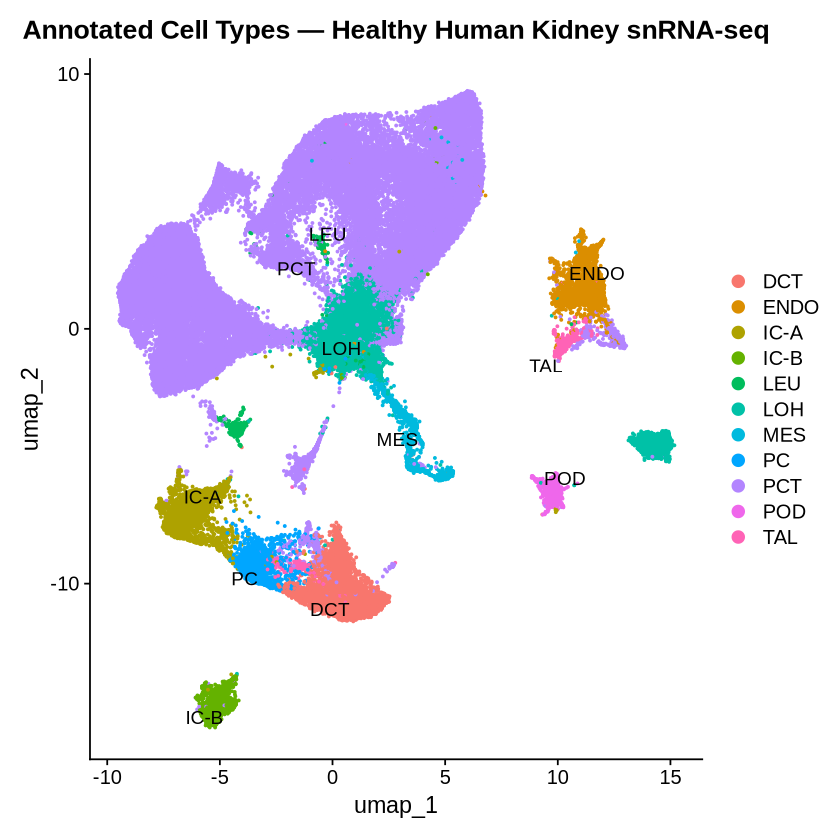

In [4]:
# ============================================================
# Cell 4: 手动注释 cluster → 细胞类型（已修复）
# 修复：unname() 避免 Seurat "No cell overlap" 错误
# 映射：根据 DotPlot + marker 表更新，覆盖 0-24 全部 cluster
# ============================================================

if (!"cell_type" %in% colnames(scrna_obj@meta.data)) {

    # ── 根据 DotPlot 的对照结果 ──────────────────────────────
    # 参考依据（marker 基因 → 细胞类型）：
    #   CUBN/LRP2          → PCT  (近端小管)
    #   SLC12A1/UMOD       → TAL  (髓袢升支粗段)
    #   CLCNKA/CLCNKB      → LOH  (髓袢细段)
    #   SLC12A3/TRPM6      → DCT  (远端小管)
    #   AQP2/AQP3          → PC   (集合管主细胞)
    #   SLC4A1/ATP6V1B1    → IC-A (A型闰细胞)
    #   SLC26A4            → IC-B (B型闰细胞)
    #   PECAM1/FLT1/NOTCH4 → ENDO (内皮细胞)
    #   PDGFRB/CARMN       → MES  (系膜/间质细胞)
    #   NPHS1/NPHS2/CFH    → POD  (足细胞)
    #   PAX8/CLDN1         → PEC  (肾小球囊上皮)
    #   PTPRC/CD74         → LEU  (白细胞)
    cluster_to_celltype <- c(
        "0"  = "LOH",   # CLCNKA, CLCNKB 强表达
        "1"  = "PCT",   # CUBN, LRP2
        "2"  = "PCT",   # CUBN, LRP2 + CYP3A5
        "3"  = "PCT",   # LRP2 强
        "4"  = "PCT",   # CUBN, LRP2
        "5"  = "PCT",   # CUBN, LRP2
        "6"  = "DCT",   # SLC12A3, TRPM6 强
        "7"  = "PCT",   # CUBN, LRP2 (GP2/SIM2 为 PCT 亚型标志)
        "8"  = "IC-A",  # SLC4A1, ATP6V1B1 强
        "9"  = "ENDO",  # FLT1, PLVAP, NOTCH4 强
        "10" = "PCT",   # CUBN, LRP2
        "11" = "IC-B",  # SLC26A4
        "12" = "PC",    # AQP2, AQP3 强
        "13" = "MES",   # CARMN, PDGFRB
        "14" = "LOH",   # PTPRQ (髓袢标志)
        "15" = "PCT",   # CUBN, LRP2 强
        "16" = "PCT",   # SLC4A4 (亦在PCT表达)
        "17" = "POD",   # NPHS1, NPHS2, CFH, KIRREL3 强
        "18" = "PCT",   # CUBN, LRP2
        "19" = "TAL",   # SLC12A1, UMOD 强
        "20" = "PCT",   # CUBN/LRP2 + FTL/FABP1 (高代谢 PCT)
        "21" = "LEU",   # ARHGAP15, CNTNAP2, ELMO1 (免疫细胞标志)
        "22" = "LEU",   # CD74 强
        "23" = "TAL",   # SLC12A1, UMOD 强
        "24" = "PCT"    # CUBN, LRP2 强
    )

    cell_type_vec <- unname(
        cluster_to_celltype[as.character(scrna_obj$seurat_clusters)]
    )
    scrna_obj$cell_type <- cell_type_vec

    # ── 检查是否有未映射的 cluster ────────────────────────────
    na_n <- sum(is.na(scrna_obj$cell_type))
    if (na_n > 0) {
        miss_cls <- unique(scrna_obj$seurat_clusters[
            is.na(scrna_obj$cell_type)])
        warning(na_n, " 个细胞未映射，未覆盖 cluster: ",
                paste(miss_cls, collapse = ", "),
                "\n请在 cluster_to_celltype 中补充")
        scrna_obj$cell_type[is.na(scrna_obj$cell_type)] <- "Unknown"
    }

    cat("细胞类型分布：\n")
    print(table(scrna_obj$cell_type))

    # 保存最终缓存
    saveRDS(scrna_obj, paths$cache$scrna_final)
    cat("\n✅ 最终 scRNA 缓存已保存:", paths$cache$scrna_final, "\n")
    cat("   下次运行将直接加载，跳过所有 scRNA 处理步骤\n")

} else {
    cat("已有 cell_type 注释，跳过\n")
    cat("如需重新注释：删除", paths$cache$scrna_final, "后重新运行\n")
}

DimPlot(scrna_obj, group.by = "cell_type",
    reduction = "umap", label = TRUE, repel = TRUE, pt.size = 0.3) +
    ggtitle("Annotated Cell Types — Healthy Human Kidney snRNA-seq")


In [5]:
# ============================================================
# Cell 5: 加载 Xenium IgAN 肾脏数据
# 缓存策略：
#   xenium_final 存在 → 直接加载（含标签转移结果，跳过全部）
#   xenium_base 存在  → 跳过 Read10X + 坐标加载
#   两者都不存在      → 从原始文件构建
#
# 修复 1：Read10X 返回 list 时提取 Gene Expression 子矩阵
# 修复 2：read.csv 直接读 .gz 路径，不用 gzcon(file(...,"rb"))
# ============================================================

if (file.exists(paths$cache$xenium_final)) {
    cat("[Cache HIT] 加载 Xenium 最终缓存（含标签转移）...\n")
    xenium_obj <- readRDS(paths$cache$xenium_final)
    cat("  细胞数:", ncol(xenium_obj), "\n")
    cat("  标签转移结果分布:\n")
    print(table(xenium_obj$predicted.id))

} else if (file.exists(paths$cache$xenium_base)) {
    cat("[Cache HIT] 加载 Xenium 基础缓存（坐标已加载，待标签转移）...\n")
    xenium_obj <- readRDS(paths$cache$xenium_base)
    cat("  细胞数:", ncol(xenium_obj), "\n")
    cat("  请继续运行 Cell 6 进行标签转移\n")

} else {
    cat("[Cache MISS] 从原始文件加载 Xenium 数据...\n")

    # ── 修复 1：Read10X 可能返回 list（多种数据类型）──────────
    xenium_raw <- Read10X(data.dir = paths$raw$xenium_dir)

    if (is.list(xenium_raw)) {
        cat("  检测到多种数据类型:", paste(names(xenium_raw), collapse = ", "), "\n")
        # 提取基因表达矩阵（忽略控制探针等）
        if ("Gene Expression" %in% names(xenium_raw)) {
            xenium_counts <- xenium_raw[["Gene Expression"]]
        } else {
            xenium_counts <- xenium_raw[[1]]
            cat("  未找到 'Gene Expression'，使用第一个矩阵:", names(xenium_raw)[1], "\n")
        }
    } else {
        xenium_counts <- xenium_raw
    }

    xenium_obj <- CreateSeuratObject(
        counts = xenium_counts, project = "Kidney_IgAN", min.cells = 3
    )
    cat("  细胞数:", ncol(xenium_obj), "\n")
    cat("  基因数:", nrow(xenium_obj), "\n")

    # ── 修复 2：直接传路径字符串，R 原生支持读取 .gz ──────────
    # 原代码：read.csv(gzcon(file(path, "rb")))
    # 问题：gzcon 创建二进制连接，read.csv 内部 pushBack 要求文本连接
    # 修复：read.csv(path) 即可，R 自动解压 .gz
    cat("  加载细胞质心坐标...\n")
    cells_meta <- read.csv(paths$raw$xenium_cells)
    cat("  cells.csv.gz 列名:", paste(colnames(cells_meta), collapse = ", "), "\n")

    # 以 cell_id 作为行名，与 Seurat barcode 对齐
    rownames(cells_meta) <- cells_meta$cell_id
    common_cells <- intersect(colnames(xenium_obj), rownames(cells_meta))
    cat("  匹配细胞数:", length(common_cells), "\n")

    xenium_obj <- xenium_obj[, common_cells]
    xenium_obj <- AddMetaData(
        xenium_obj,
        metadata = cells_meta[common_cells,
            c("x_centroid", "y_centroid", "transcript_counts",
              "cell_area", "nucleus_area")]
    )
    cat("  x_centroid 范围:",
        round(min(xenium_obj$x_centroid), 1), "~",
        round(max(xenium_obj$x_centroid), 1), "μm\n")

    # 保存基础缓存
    saveRDS(xenium_obj, paths$cache$xenium_base)
    cat("✅ Xenium 基础缓存已保存:", paths$cache$xenium_base, "\n")
    cat("   下次运行将跳过 Read10X + 坐标加载\n")
}


[Cache MISS] 从原始文件加载 Xenium 数据...


10X data contains more than one type and is being returned as a list containing matrices of each type.

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


  细胞数: 30802 
  基因数: 419 


ERROR: Error in pushBack(c(lines, lines), file, encoding = pbEncoding): can only push back on text-mode connections


In [ ]:
# ============================================================
# Cell 6: Seurat 标签转移（最耗时，约 20-40 分钟）
# 缓存策略：xenium_final 存在则跳过（Cell 5 已处理）
# ============================================================

if (file.exists(paths$cache$xenium_final) &&
    "predicted.id" %in% colnames(xenium_obj@meta.data)) {
    cat("[Cache HIT] Xenium 标签转移结果已存在，跳过\n")

} else {
    cat("[Cache MISS] 运行 Seurat 标签转移（约 20-40 分钟）...\n")

    common_genes <- intersect(rownames(scrna_obj), rownames(xenium_obj))
    cat("  共同基因数:", length(common_genes), "\n")

    scrna_sub  <- scrna_obj[common_genes, ]
    xenium_sub <- xenium_obj[common_genes, ]
    DefaultAssay(xenium_sub) <- "RNA"

    cat("  寻找锚点...\n")
    anchors <- FindTransferAnchors(
        reference            = scrna_sub,
        query                = xenium_sub,
        normalization.method = "LogNormalize",
        reference.reduction  = "harmony",
        dims                 = 1:params$n_pcs
    )

    cat("  转移标签...\n")
    predictions <- TransferData(
        anchorset = anchors,
        refdata   = scrna_obj$cell_type,
        dims      = 1:params$n_pcs
    )
    xenium_obj <- AddMetaData(xenium_obj, metadata = predictions)

    # 保存最终 Xenium 缓存
    saveRDS(xenium_obj, paths$cache$xenium_final)
    cat("\n✅ Xenium 最终缓存已保存:", paths$cache$xenium_final, "\n")
    cat("   下次运行将直接加载，跳过标签转移\n")
}

cat("\nSeurat 标签转移结果分布（定性参考）：\n")
print(table(xenium_obj$predicted.id))

In [ ]:
# ============================================================
# Cell 7: 完成确认 + 缓存状态汇总
# ============================================================

cat("=== 所有步骤完成 ===\n\n")
cat("缓存文件状态：\n")
for (nm in names(paths$cache)) {
    f    <- paths$cache[[nm]]
    ex   <- file.exists(f)
    size <- if (ex) paste0(round(file.size(f)/1e6, 1), " MB") else "不存在"
    cat(sprintf("  %-25s %s  (%s)\n", nm, if (ex) "✅" else "❌", size))
}

cat("\n下次运行时各 Cell 的耗时：\n")
cat("  Cell 2: ~5 秒（直接加载 scrna_final）\n")
cat("  Cell 3: 跳过（已有 cell_type）\n")
cat("  Cell 4: 跳过（已有 cell_type）\n")
cat("  Cell 5: ~10 秒（直接加载 xenium_final）\n")
cat("  Cell 6: 跳过（xenium_final 已含标签转移）\n")

cat("\n下一步：运行 train_copy_spot_level.ipynb\n")